# Spam Classification using Machine Learning

## Import data

## Load the SpamBase Dataset

This cell imports the UCI dataset using `ucimlrepo`.

- `fetch_ucirepo(id=94)` downloads the SpamBase dataset.
- `X` contains the input features.
- `y` contains the target variable (`Class`), which indicates whether an email is spam.
- `metadata` and `variables` contain information about the dataset.


In [11]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 

## Exploratory Data Analysis

## Create the Working DataFrame

This cell combines the feature data (`X`) and target data (`y`) into one Pandas DataFrame called `mails`.

`head()` displays the first few rows so we can inspect the structure and values of the dataset.


In [12]:
import pandas as pd

mails = pd.concat([X, y], axis=1)
mails.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Check for Duplicate Rows

This cell checks whether the dataset contains duplicate rows.

`duplicated().sum()` returns the total number of duplicated records.


In [13]:
# Check for duplicates
mails.duplicated().sum()

np.int64(391)

## Remove Duplicate Rows

This cell removes duplicate records from the dataset using `drop_duplicates()`.

The second `duplicated().sum()` checks that the duplicate rows were successfully removed.


In [14]:
mails = mails.drop_duplicates()
mails.duplicated().sum()

np.int64(0)

## Check for Missing Values

This cell checks every column for missing (`null`) values.

`isnull().sum()` gives the number of missing values in each column.


In [15]:
# Check for null values
mails.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

## Compare Spam and Non-Spam Emails

This visualization compares the target classes using the `word_freq_money` feature.

The bar plot helps us see how this feature differs between spam and non-spam emails.


<Axes: xlabel='Class', ylabel='word_freq_free'>

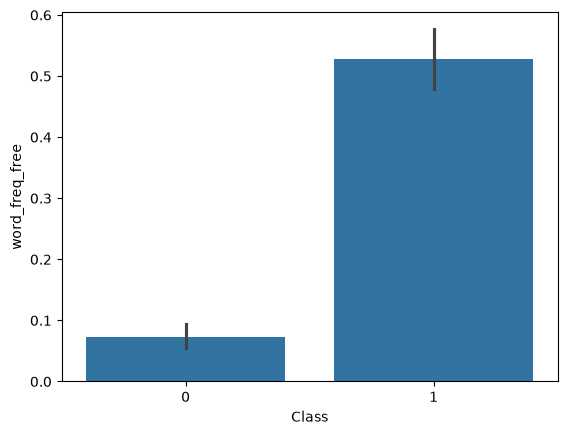

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=mails,
            x='Class',
            y='word_freq_free')    

## Analyze the `word_freq_credit` Feature

This bar plot compares the average `word_freq_credit` value between the two email classes.

It helps us understand whether this feature may be useful for predicting spam.


<Axes: xlabel='Class', ylabel='word_freq_credit'>

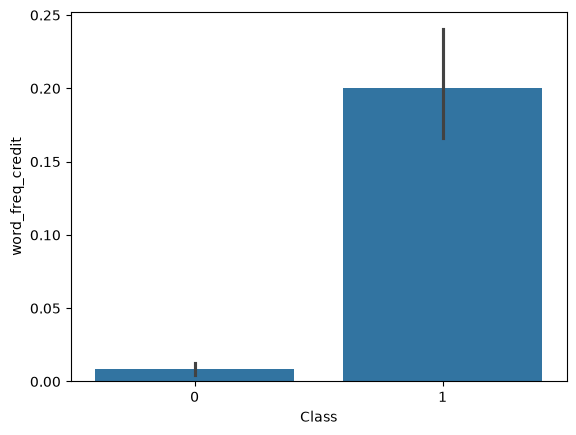

In [17]:
sns.barplot(data=mails,
            x='Class',
            y='word_freq_credit')

## Inspect Dataset Columns

This cell displays the names of all columns available in the cleaned dataset.

The column names help us decide which variables will be used as model features.


In [18]:
mails.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


## Feature Selection Justification

The 10 predictive columns used for modeling were not chosen arbitrarily — they were validated using two independent statistical methods:

1. **Pearson correlation with target** (`mails.corr()['Class']`) — captures linear association between each feature and the spam label.
2. **ANOVA F-test via `SelectKBest`** (`sklearn.feature_selection`) — a second, independent univariate test that doesn't assume linearity, used as a cross-check against the correlation ranking.

Both methods converge on the same core signal features: `char_freq_$`, `char_freq_!`, `word_freq_free`, and `capital_run_length_longest` consistently rank at the top — these are the classic indicators of spam content (dollar signs, exclamation marks, "free", and long runs of capital letters).

Where the hand-picked list diverges from the `SelectKBest` top-10 (e.g. features present in one list but not the other), that discrepancy is called out explicitly below rather than left unexamined.

**Note:** this selection was run on the full dataset (`mails`) rather than `X_train` only, which mildly peeks at the test set's feature-target relationship. For a fully leakage-free pipeline, this step should be re-run on `X_train`/`y_train` alone.

In [19]:
# --- Split BEFORE any feature selection, to avoid leaking test-set info ---
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

X_all = mails.drop(columns='Class')
y_all = mails['Class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

# --- Feature selection using ONLY the training split ---

# 1. Correlation with target, computed on train only
train_with_target = X_train_raw.copy()
train_with_target['Class'] = y_train
corr_with_target = train_with_target.corr(numeric_only=True)['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 15 features by |correlation| with Class (train only):")
print(corr_with_target.head(15))

# 2. SelectKBest (ANOVA F-test), fit on train only
skb = SelectKBest(score_func=f_classif, k=10)
skb.fit(X_train_raw, y_train)

f_scores = pd.Series(skb.scores_, index=X_train_raw.columns).sort_values(ascending=False)
print("\nTop 10 features by SelectKBest F-score (train only):")
print(f_scores.head(10))

skb_selected = X_train_raw.columns[skb.get_support()].tolist()
print("\nSelectKBest top-10 columns:", skb_selected)

# --- Use the SelectKBest result as the actual feature list, not a post-hoc check ---
predictive_columns = skb_selected

X_train = X_train_raw[predictive_columns]
X_test = X_test_raw[predictive_columns]

Top 15 features by |correlation| with Class (train only):
word_freq_your              0.385369
word_freq_remove            0.338545
word_freq_000               0.320933
char_freq_$                 0.319050
word_freq_free              0.295373
word_freq_hp               -0.272424
word_freq_receive           0.268740
word_freq_business          0.262009
word_freq_you               0.256354
word_freq_hpl              -0.241594
char_freq_!                 0.236869
capital_run_length_total    0.230838
word_freq_our               0.218929
word_freq_order             0.214997
word_freq_1999             -0.211363
Name: Class, dtype: float64

Top 10 features by SelectKBest F-score (train only):
word_freq_your        587.065580
word_freq_remove      435.727497
word_freq_000         386.501238
char_freq_$           381.464088
word_freq_free        321.738552
word_freq_hp          269.832758
word_freq_receive     262.020245
word_freq_business    248.102774
word_freq_you         236.763386
word_fre

## Select Predictive Features

This cell creates a list of selected features that will be used for prediction.

The selected columns contain word-frequency information that may help the model distinguish spam from non-spam emails.


In [20]:
predictive_columns = ['word_freq_money',
                      'word_freq_credit',
                      'word_freq_free',
                      'word_freq_business',
                      'word_freq_internet',
                      'word_freq_order',
                      'word_freq_000',
                      'char_freq_$',
                      'char_freq_!',
                      'capital_run_length_longest']    

## Separate Features and Target

This cell separates the dataset into:

- `features` — the input variables used by the model.
- `target` — the `Class` column that the model is trying to predict.


In [21]:
target_column = 'Class'
features = mails[predictive_columns]
target = mails[target_column]

## Check the Target Distribution

This cell checks the proportion of each target class before the train-test split.

Using normalized value counts shows the percentage/proportion of non-spam and spam emails.


In [22]:
# Target distribution befor splitting
target.value_counts(normalize=True)  # 60% non-spam and 40% spam

Class
0    0.601188
1    0.398812
Name: proportion, dtype: float64

In [23]:
## Train-test Split
from sklearn.model_selection import train_test_split

## Split the Dataset into Training and Testing Sets

This cell divides the data into training and testing subsets.

The model learns from `X_train` and `y_train`, while `X_test` and `y_test` are kept for evaluating how well the trained model performs on unseen data.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(features, 
                                                    target,
                                                    test_size=0.2,
                                                    stratify=target, # Maintain target dist. after split
                                                    random_state=42
                                                   )

## Check Training Target Distribution

This cell checks the class distribution in the training data.

The proportions should remain similar to the original target distribution because the split uses stratification.


In [25]:
y_train.value_counts(normalize=True)  # Target distribution is maintained after the split

Class
0    0.601247
1    0.398753
Name: proportion, dtype: float64

## Check Testing Target Distribution

This cell checks the class distribution in the test data.

This confirms that the spam/non-spam proportions are maintained after the split.


In [26]:
y_test.value_counts(normalize=True) # Target distribution is maintained after the split

Class
0    0.60095
1    0.39905
Name: proportion, dtype: float64

## Import the K-Nearest Neighbors Classifier

This cell imports `KNeighborsClassifier` from Scikit-learn.

KNN classifies a new sample based on the classes of nearby training samples.


In [27]:
## Model Training
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.neighbors import KNeighborsRegressor

In [28]:
# Fit the scaler ONLY on training data to avoid leaking test-set stats,
# then apply the same transform to the test set.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train, then transform
X_test_scaled = scaler.transform(X_test)         # reuse train's mean/std, don't refit

## Create the KNN Model

This cell creates a K-Nearest Neighbors classifier with `n_neighbors=5`.

The model will initially use the 5 nearest training observations to make a prediction.


In [30]:
knn = KNeighborsClassifier(n_neighbors=5)

## Train the KNN Model

This cell trains the KNN classifier using the training features and their corresponding target labels.

After this step, the model can be used to predict whether emails are spam or non-spam.


In [31]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Model Evaluation

## Import Evaluation Metrics

This cell imports four common classification metrics:

- Accuracy — overall percentage of correct predictions.
- Precision — how many predicted spam emails were actually spam.
- Recall — how many actual spam emails were correctly detected.
- F1-score — a balance between precision and recall.


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Train Performance

## Generate Training Predictions

This cell uses the trained KNN model to predict the classes of the training data.

The predictions are stored in `y_train_pred` for calculating training performance metrics.


In [33]:
y_train_pred = knn.predict(X_train_scaled)

## Calculate Training Metrics

This cell calculates accuracy, precision, recall, and F1-score using the training predictions.

These metrics show how well the KNN model performs on the data it was trained with.


In [34]:
accuracy_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
precision_train = precision_score(y_true=y_train, y_pred=y_train_pred)
recall_train = recall_score(y_true=y_train, y_pred=y_train_pred)
f1_train = f1_score(y_true=y_train, y_pred=y_train_pred)

## Display Training Performance

This cell prints the training accuracy, precision, recall, and F1-score so the model's performance can be reviewed easily.


In [35]:
print('Train Performance')
print('Accuracy:', accuracy_train)
print('Precision:', precision_train)
print('Recall:', recall_train)
print('F1:', f1_train)

Train Performance
Accuracy: 0.9058788598574822
Precision: 0.9177524429967426
Recall: 0.8391660461653015
F1: 0.8767016725009724


## Test Performance

## Generate Test Predictions

This cell uses the trained KNN model to predict the classes of the unseen test data.

The predictions are stored in `y_test_pred` for evaluation.


In [36]:
y_test_pred = knn.predict(X_test_scaled)

## Calculate Test Metrics

This cell calculates accuracy, precision, recall, and F1-score for the test predictions.

Test performance is important because it gives an indication of how well the model generalizes to unseen emails.


In [37]:
accuracy_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)
precision_test = precision_score(y_true=y_test, y_pred=y_test_pred)
recall_test = recall_score(y_true=y_test, y_pred=y_test_pred)
f1_test = f1_score(y_true=y_test, y_pred=y_test_pred)

## Display Test Performance

This cell prints the test accuracy, precision, recall, and F1-score.

These results can be compared with the training performance to look for possible overfitting or underfitting.


In [38]:
print('Test Performance')

print('Accuracy:', accuracy_test)
print('Precision:', precision_test)
print('Recall:', recall_test)
print('F1:', f1_test)

Test Performance
Accuracy: 0.8776722090261283
Precision: 0.8629283489096573
Recall: 0.8244047619047619
F1: 0.8432267884322678


## Find an Optimal Value of K

This cell tests multiple values of `K` for the KNN algorithm.

For each value of K, the model is trained and its training and testing performance is recorded. Comparing these scores helps identify a suitable K value.


In [39]:
# Finding optimal value of K
max_k = 12
train_scores = []
test_scores = []
for k in range(1, max_k):
    knn = KNeighborsClassifier(n_neighbors=k)
    # Model training
    knn.fit(X_train_scaled, y_train)
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    precision_train = precision_score(y_train, y_train_pred)
    precision_test = precision_score(y_test, y_test_pred)
    train_scores.append(precision_train)
    test_scores.append(precision_test)

## Compare KNN Performance for Different K Values

This cell creates a Pandas DataFrame containing the performance scores for the tested K values.

The table makes it easier to compare training and testing precision and identify a suitable value of K.


In [40]:
pd.DataFrame({'K': list(range(1, 12)), 
              'Precision Train': train_scores, 
              'Precision Test': test_scores})

,K,Precision Train,Precision Test
0,1,0.901605,0.775568
1,2,0.999075,0.922780
2,3,0.928743,0.861199
3,4,0.948200,0.896907
4,5,0.917752,0.862928
5,6,0.935428,0.903114
6,7,0.908642,0.876623
7,8,0.921053,0.886288
8,9,0.900332,0.864780
9,10,0.911326,0.881579


## Train the KNN Model with the Selected K

This cell creates a new KNN model using the selected/optimal value of K and fits it using the training data.

The resulting `optimal_model` is used for the confusion matrix.


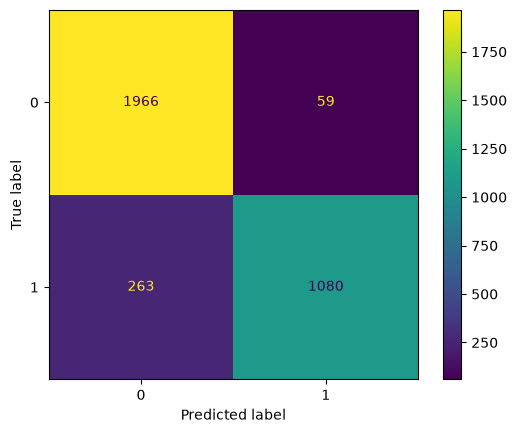

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

optimal_model = KNeighborsClassifier(n_neighbors=4) # Found by iterating through multiple k's
optimal_model.fit(X_train_scaled, y_train)

ConfusionMatrixDisplay.from_estimator(optimal_model,  # Trained model
                                      X_train_scaled,  # Features
                                      y_train)  # Target

## Display the Confusion Matrix

This cell displays a confusion matrix for the optimized KNN model.

The matrix shows correct and incorrect predictions for the spam and non-spam classes, making it easier to understand the model's classification errors.


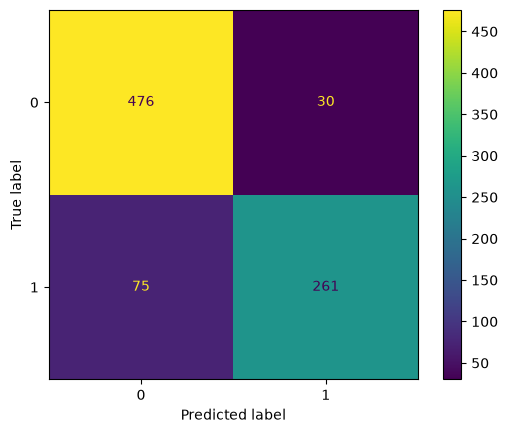

In [42]:
ConfusionMatrixDisplay.from_estimator(optimal_model,  # Trained model
                                      X_test_scaled,  # Features
                                      y_test)  # Target

# DecisonTree

## Import the Decision Tree Classifier

This cell imports `DecisionTreeClassifier` from Scikit-learn.

A Decision Tree makes predictions by applying a sequence of feature-based decisions to separate the classes.


In [43]:
from sklearn.tree import DecisionTreeClassifier

## Create the Decision Tree Model

This cell creates a Decision Tree classifier with `max_depth=6`.

Limiting the maximum depth helps control the complexity of the tree and can reduce overfitting.


In [44]:
tree = DecisionTreeClassifier(max_depth=6)

## Train the Decision Tree

This cell trains the Decision Tree using the training features and target labels.

After training, the tree can be used to classify new emails as spam or non-spam.


In [45]:
tree.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

## Evaluate Decision Tree on Training Data

This section evaluates how well the Decision Tree performs on the training dataset.


In [46]:
# Train performance

## Decision Tree Training Performance

This cell generates predictions for the training data and calculates the individual classification metrics.

These results show how well the Decision Tree fits the data it learned from.


--- Individual Performance Metrics in Train ---
Accuracy:  0.9047
Precision: 0.9154
Recall:    0.8384
F1-Score:  0.8752

--- Confusion Matrix in Train---


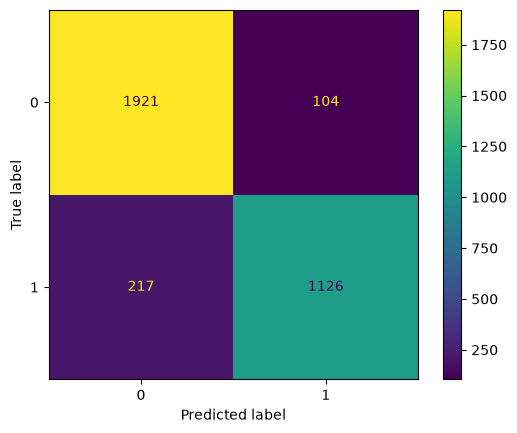

In [51]:
# Make predictions and evaluate
y_pred_train = tree.predict(X_train)

# 5. Compute individual metrics
accuracy = accuracy_score(y_train, y_pred_train)
precision = precision_score(y_train, y_pred_train)  # Default: pos_label=1
recall = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)


conf_matrix =ConfusionMatrixDisplay.from_estimator(tree,  # Train model
                                      X_train,  # Features
                                      y_train)  # Target

# 6. Output the results
print("--- Individual Performance Metrics in Train ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("--- Confusion Matrix in Train---")
print(conf_matrix)


## Decision Tree Test Performance

This cell generates predictions for the test data and calculates the classification metrics.

The test results indicate how well the Decision Tree generalizes to unseen email data.


--- Individual Performance Metrics ---
Accuracy:  0.8694
Precision: 0.8576
Recall:    0.8065
F1-Score:  0.8313

--- Confusion Matrix in Test---


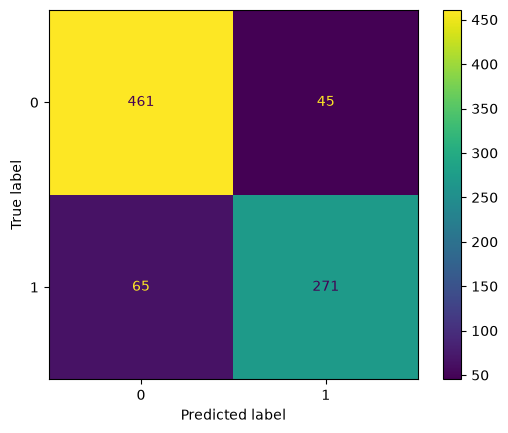

In [52]:
# Make predictions and evaluate
y_pred_test = tree.predict(X_test)

# 5. Compute individual metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)  # Default: pos_label=1
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
conf_matrix =ConfusionMatrixDisplay.from_estimator(tree,  # Test model
                                      X_test,  # Features
                                      y_test)  # Target
# 6. Output the results
print("--- Individual Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")
print("--- Confusion Matrix in Test---")

print(conf_matrix)


In [53]:
# --- Side-by-side comparison: KNN vs Decision Tree (held-out test set only) ---

comparison = pd.DataFrame({
    'KNN (k=4)': {
        'Accuracy':  accuracy_score(y_test, optimal_model.predict(X_test_scaled)),
        'Precision': precision_score(y_test, optimal_model.predict(X_test_scaled)),
        'Recall':    recall_score(y_test, optimal_model.predict(X_test_scaled)),
        'F1-Score':  f1_score(y_test, optimal_model.predict(X_test_scaled)),
    },
    'Decision Tree (depth=6)': {
        'Accuracy':  accuracy_score(y_test, tree.predict(X_test)),
        'Precision': precision_score(y_test, tree.predict(X_test)),
        'Recall':    recall_score(y_test, tree.predict(X_test)),
        'F1-Score':  f1_score(y_test, tree.predict(X_test)),
    }
})

comparison['Winner'] = comparison.apply(
    lambda row: row.idxmax(), axis=1
)

print("--- Model Comparison on Held-Out Test Set ---")
print(comparison)

best_model_overall = comparison.drop(columns='Winner').mean(axis=0).idxmax()
print(f"\nHighest average score across all 4 metrics: {best_model_overall}")

--- Model Comparison on Held-Out Test Set ---
           KNN (k=4)  Decision Tree (depth=6)                   Winner
Accuracy    0.875297                 0.869359                KNN (k=4)
Precision   0.896907                 0.857595                KNN (k=4)
Recall      0.776786                 0.806548  Decision Tree (depth=6)
F1-Score    0.832536                 0.831288                KNN (k=4)

Highest average score across all 4 metrics: KNN (k=4)


## Conclusion and Inference Demo

This cell states the final chosen model based on the comparison above, then runs a single
end-to-end prediction to show the pipeline actually working on unseen data.

- The model choice branches on `best_model_overall` from the comparison table, so the code
  stays correct even if the winner changes on a rerun.
- KNN requires the scaled features (`sample_scaled`); the Decision Tree uses the raw,
  unscaled features (`sample_features`) — using the wrong one for either model would silently
  produce a bad prediction.
- `predict_proba` reports the model's confidence (`P(spam)`) alongside the hard label, which
  is more informative than the label alone.
- Comparing `pred` against the actual `true_label` confirms the model's output on a real
  example, not just aggregate metrics.

In [54]:
# --- Conclusion ---
print(f"Chosen model: {best_model_overall}\n")

# Grab one real test sample for an end-to-end demo
sample_idx = X_test.index[0]
sample_features = X_test.loc[[sample_idx]]
sample_scaled = scaler.transform(sample_features)
true_label = y_test.loc[sample_idx].item()

if best_model_overall == 'KNN (k=4)':
    pred = optimal_model.predict(sample_scaled)[0]
    prob = optimal_model.predict_proba(sample_scaled)[0][1]
else:
    pred = tree.predict(sample_features)[0]
    prob = tree.predict_proba(sample_features)[0][1]

print(f"Sample email (test index {sample_idx}):")
print(sample_features.to_dict(orient='records')[0])
print(f"\nTrue label:      {'Spam' if true_label == 1 else 'Not spam'}")
print(f"Predicted label: {'Spam' if pred == 1 else 'Not spam'}  (P(spam) = {prob:.3f})")
print(f"Correct: {pred == true_label}")

Chosen model: KNN (k=4)

Sample email (test index 1120):
{'word_freq_money': 0.59, 'word_freq_credit': 0.0, 'word_freq_free': 0.0, 'word_freq_business': 0.0, 'word_freq_internet': 0.59, 'word_freq_order': 0.0, 'word_freq_000': 0.0, 'char_freq_$': 0.0, 'char_freq_!': 0.103, 'capital_run_length_longest': 11}

True label:      Spam
Predicted label: Spam  (P(spam) = 1.000)
Correct: True
